### Mini Project: Predicting Employee Attrition Using Classification Models on the IBM HR Analytics Dataset

Note: This is a graded assignment and contributes to your overall course evaluation. You’ll apply key data science techniques to a real-world problem dataset to demonstrate your analytical and modelling abilities. 


Learning outcomes addressed:

Perform exploratory data analysis using Python libraries
Apply classification techniques and evaluate model performance
Handle data preprocessing tasks including class imbalance and feature engineering
Overview: Build a classification model to identify if an employee is likely to leave the organisation using HR data.

What this is about:
You’ll work with the IBM HR Analytics dataset containing attributes such as satisfaction level, job role, work-life balance, salary, and overtime status. The goal is to:

1. Explore patterns in attrition
1. Handle class imbalance
1. Train multiple classification models
1. Evaluate using suitable metrics
1. Extract and report key attrition driver

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('data.csv')

## Step 1: Exploratory Data Analysis (EDA)

The objective of EDA is to understand the structure, quality, and characteristics of the dataset and identify factors that may influence employee attrition.

#### Dataset Size

Understand the overall dimensions of the dataset by examining the number of rows and columns.

In [3]:
df.shape

(1470, 35)

#### Dataset Preview

Inspect a sample of records to gain familiarity with the available features and their values.

In [4]:
df.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1253,33,No,Non-Travel,1283,Sales,2,3,Marketing,1,1756,4,Female,62,3,2,Sales Executive,2,Single,5147,10697,8,Y,No,15,3,4,80,0,13,2,2,11,7,1,7
774,55,No,Non-Travel,444,Research & Development,2,1,Medical,1,1074,3,Male,40,2,4,Manager,1,Single,16756,17323,7,Y,No,15,3,2,80,0,31,3,4,9,7,6,2
340,37,No,Travel_Rarely,1192,Research & Development,5,2,Medical,1,460,4,Male,61,3,2,Manufacturing Director,4,Divorced,6347,23177,7,Y,No,16,3,3,80,2,8,2,2,6,2,0,4
639,49,No,Travel_Rarely,1418,Research & Development,1,3,Technical Degree,1,887,3,Female,36,3,1,Research Scientist,1,Married,3580,10554,2,Y,No,16,3,2,80,1,7,2,3,4,2,0,2
631,44,No,Travel_Rarely,986,Research & Development,8,4,Life Sciences,1,874,1,Male,62,4,1,Laboratory Technician,4,Married,2818,5044,2,Y,Yes,24,4,3,80,1,10,2,2,3,2,0,2


#### Data Types

Review the data types of each feature to determine the appropriate preprocessing and analysis techniques.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

#### Missing Value Analysis

Check for null or missing values that may require treatment before model development.

In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

#### Statistical Summary

Examine the central tendency, spread, and distribution of numerical features.

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


#### Duplicate Record Check

Identify duplicate observations that could introduce bias into the analysis.

In [8]:
df.duplicated().sum()

np.int64(0)

#### Correlation Analysis

Analyze relationships between numerical features and identify potentially redundant variables.

In [9]:
df.select_dtypes(include=['number']).corr()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,0.028051,0.299635,0.003634,0.001904,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,-0.032182,0.038153,0.022704,0.000473,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,0.027473,-0.029251,0.040235,0.027110,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,-0.026084,0.126317,-0.011111,-0.024539,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,-0.046247,-0.014829,0.012648,-0.001251,-0.012944,-0.020359,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,0.037600,0.012594,-0.031701,-0.029548,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,-0.071335,-0.015794,-0.015297,0.022157,-0.009062,-0.002172,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,-0.021476,-0.015271,-0.016322,0.015012,-0.017205,-0.029071,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,-0.001944,0.950300,0.039563,0.142501,-0.034730,-0.021222,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


#### Univariate Analysis

Analyze each feature independently to understand its distribution and characteristics.

##### Analysis of Categorical Features

Explore the distribution of categorical variables across the employee population.

In [10]:

df.select_dtypes(include=['object']).nunique().sort_values(ascending=False)


/var/folders/_b/sq9v3gc17zs5yj55grdmnjwc0000gp/T/ipykernel_40896/3428224698.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).nunique().sort_values(ascending=False)


JobRole           9
EducationField    6
BusinessTravel    3
Department        3
MaritalStatus     3
Attrition         2
Gender            2
OverTime          2
Over18            1
dtype: int64

> **Note**
>
> - **`Over18`** has been excluded from the analysis as it contains only a single unique value and does not provide any meaningful information.
> - **`Attrition`** has been excluded from the univariate categorical analysis since it is the target va

/var/folders/_b/sq9v3gc17zs5yj55grdmnjwc0000gp/T/ipykernel_40896/541991236.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in df.select_dtypes(include=['object']).columns


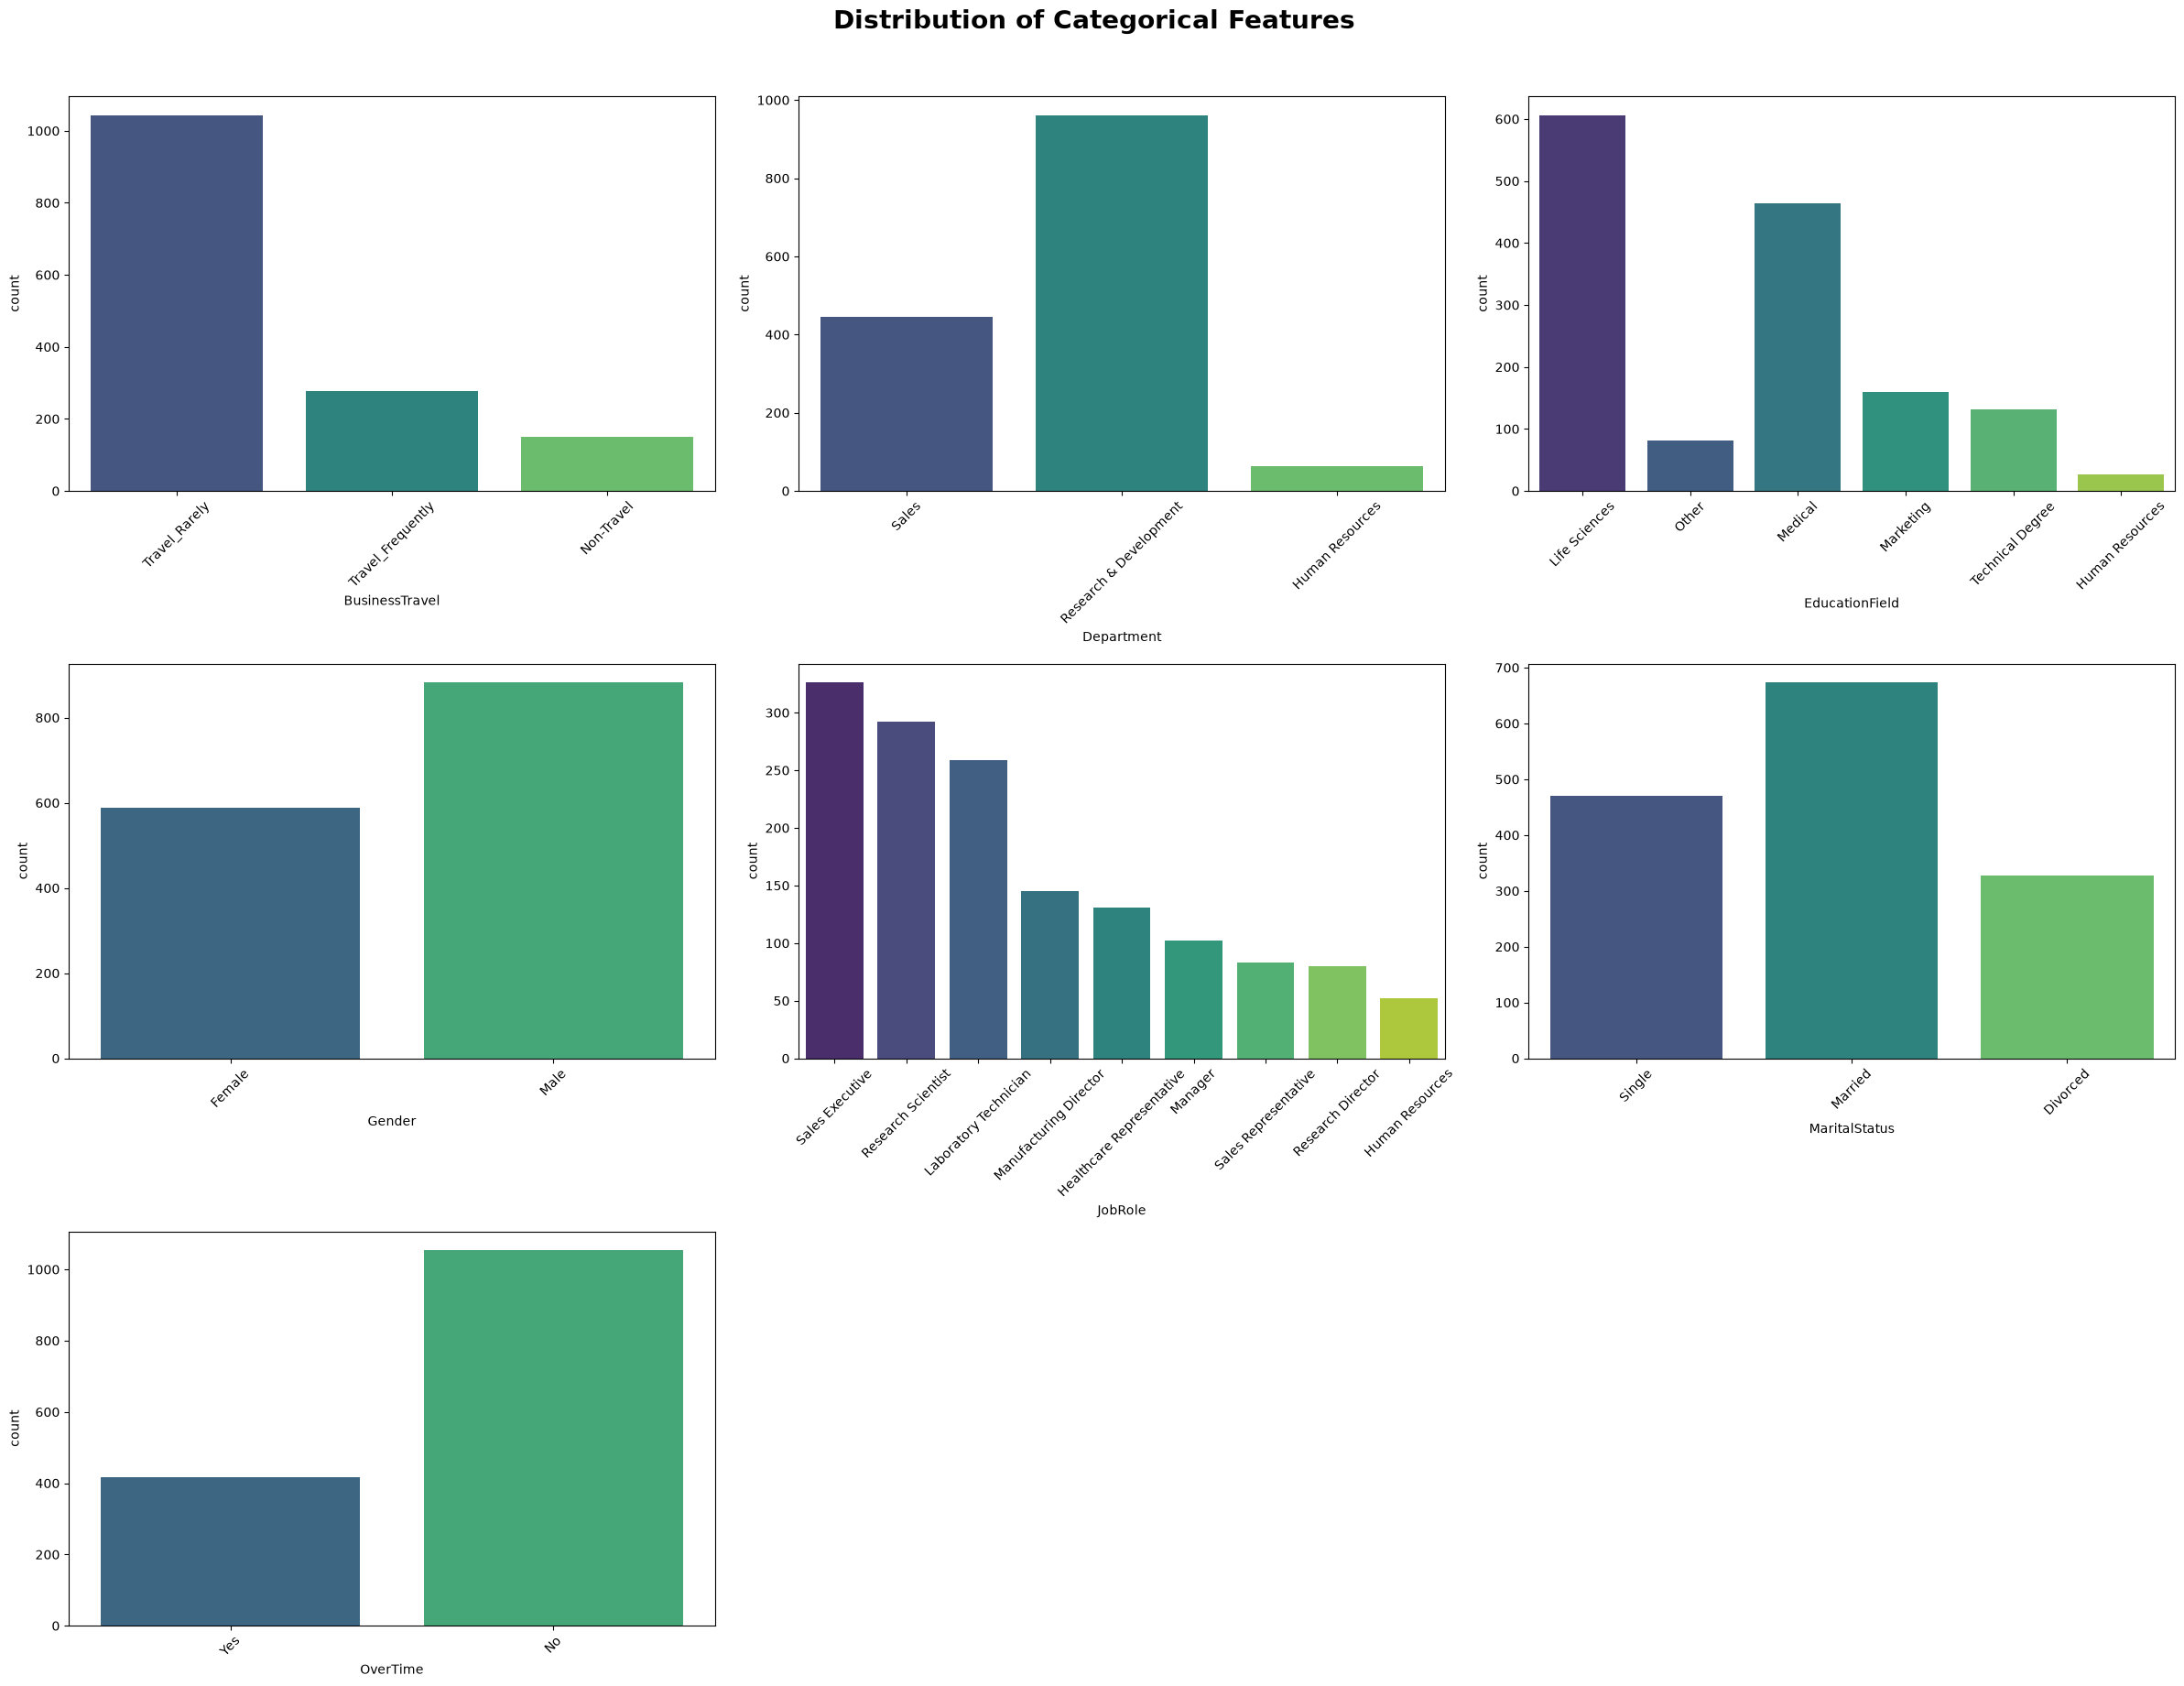

In [11]:

categorical_columns = [
    col for col in df.select_dtypes(include=['object']).columns
    if col not in ['Attrition', 'Over18']
]

n_cols = 3
n_rows = math.ceil(len(categorical_columns) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(24, 6*n_rows)
)

# Overall title
fig.suptitle(
    'Distribution of Categorical Features',
    fontsize=20,
    fontweight='bold',
    y=1.02
)

axes = axes.flatten()

for i, col in enumerate(categorical_columns):

    sns.countplot(
        data=df,
        x=col,
        hue=col,
        palette='viridis',
        legend=False,
        ax=axes[i]
    )

    axes[i].tick_params(axis='x', rotation=45)

# Remove empty plots
for j in range(len(categorical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

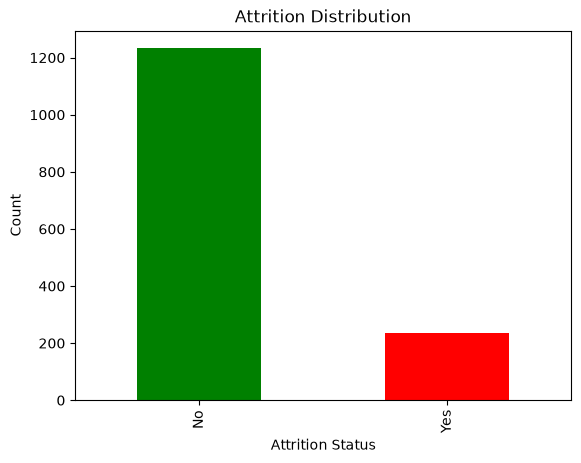

In [12]:
df['Attrition'].value_counts().plot(
    kind='bar',
    color=['green', 'red']
)

plt.title('Attrition Distribution')
plt.xlabel('Attrition Status')
plt.ylabel('Count')
plt.show()

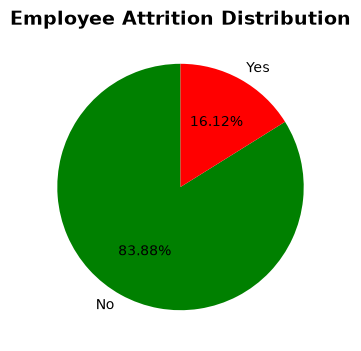

In [13]:
plt.figure(figsize=(6,4))

df['Attrition'].value_counts().plot(
    kind='pie',
    colors=['green', 'red'],
    autopct='%.2f%%',
    startangle=90
)

plt.title('Employee Attrition Distribution', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()

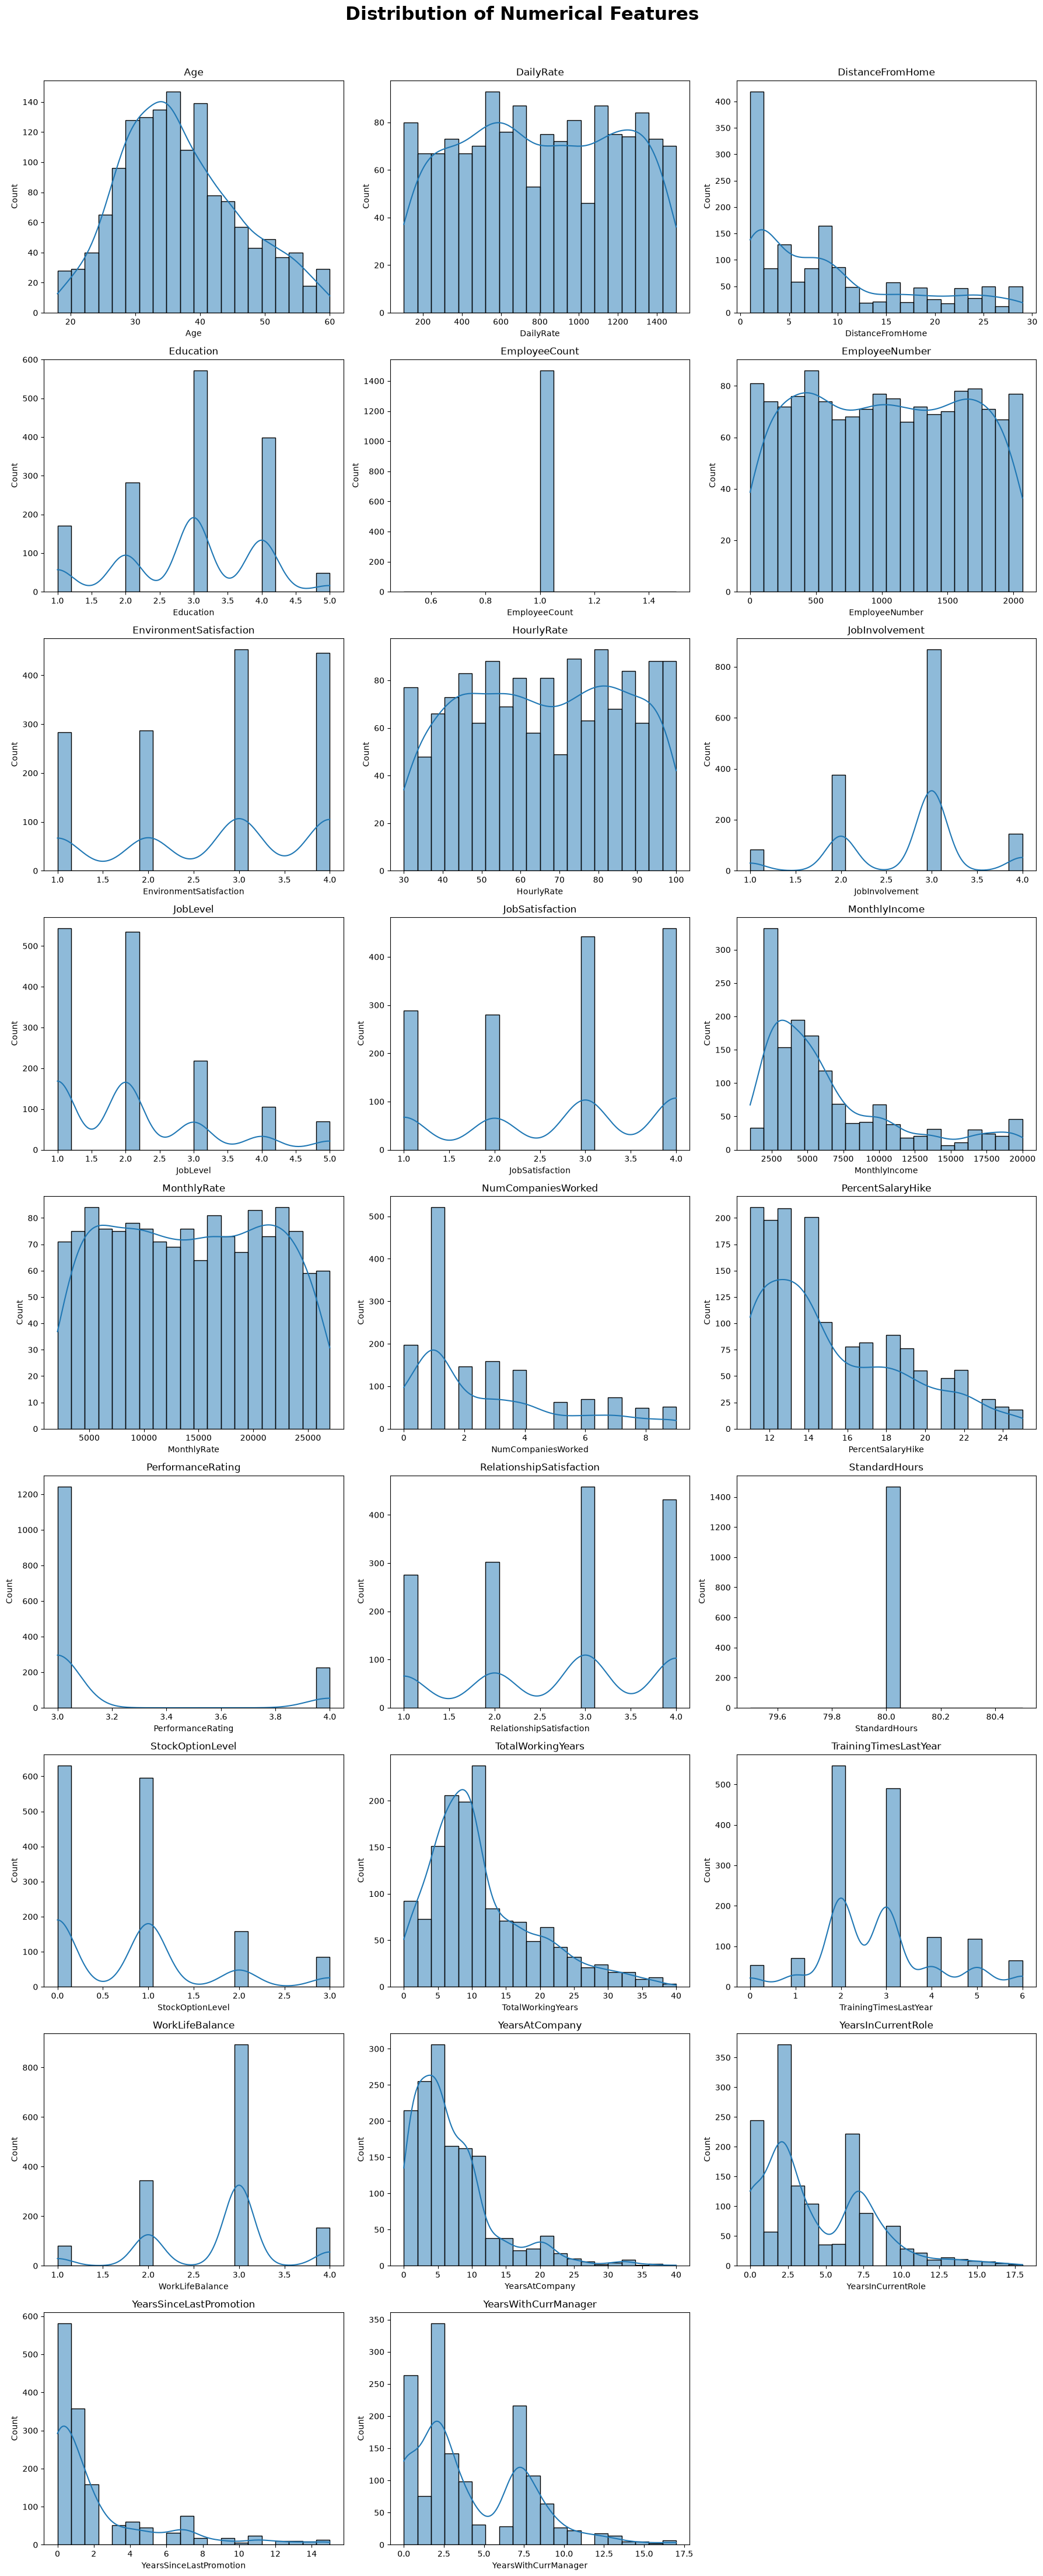

In [14]:
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()

n_cols = 3
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(
        df[col],
        bins=20,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Distribution of Numerical Features',
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#### Bivariate Analysis

Study the relationship between employee attrition and other features to identify potential attrition drivers.

##### Categorical Features vs Attrition

Evaluate how attrition varies across departments, job roles, overtime, marital status, and other categorical variables.

/var/folders/_b/sq9v3gc17zs5yj55grdmnjwc0000gp/T/ipykernel_40896/1140368936.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in df.select_dtypes(include=['object']).columns


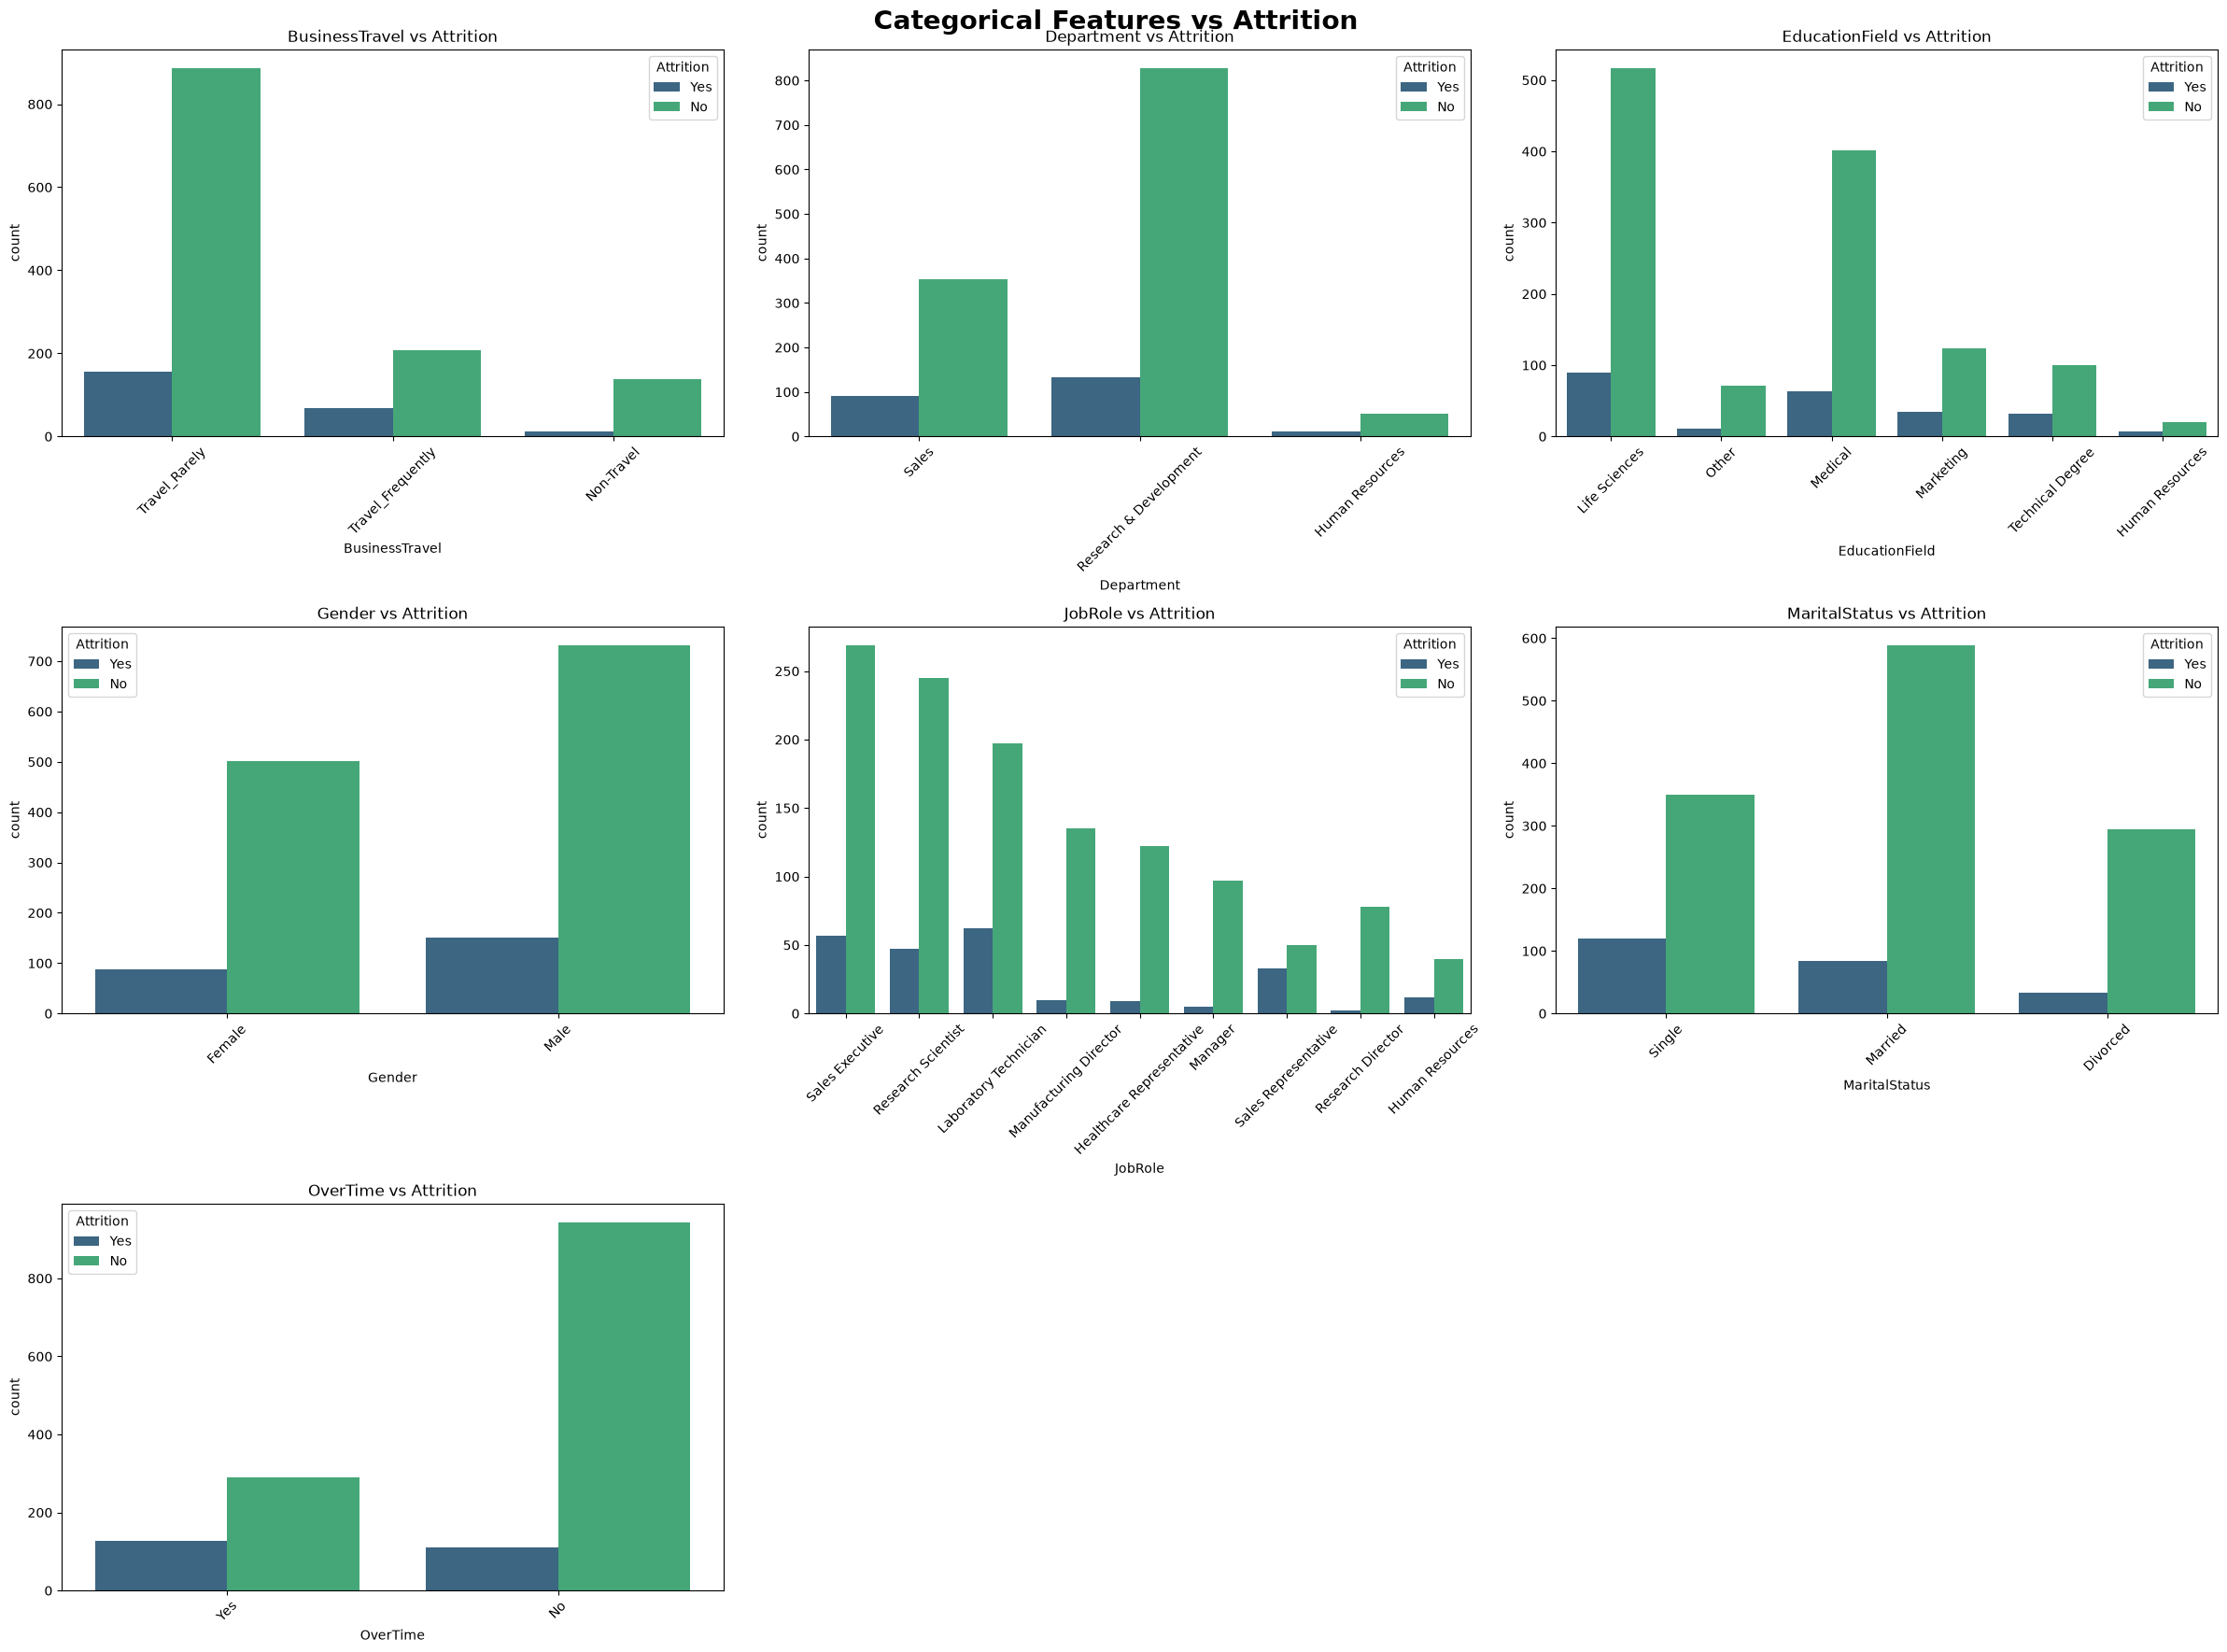

In [15]:
categorical_features_bivariate = [
    col for col in df.select_dtypes(include=['object']).columns
    if col not in ['Attrition', 'Over18']
]

n_cols = 3
n_rows = math.ceil(len(categorical_features_bivariate) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(24, 6 * n_rows)
)

fig.suptitle(
    'Categorical Features vs Attrition',
    fontsize=20,
    fontweight='bold'
)

axes = axes.flatten()

for i, col in enumerate(categorical_features_bivariate):
    sns.countplot(
        data=df,
        x=col,
        hue='Attrition',
        palette='viridis',
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs Attrition')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(categorical_features_bivariate), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### Numerical Features vs Attrition

Compare numerical feature distributions between employees who stayed and employees who left the organization.

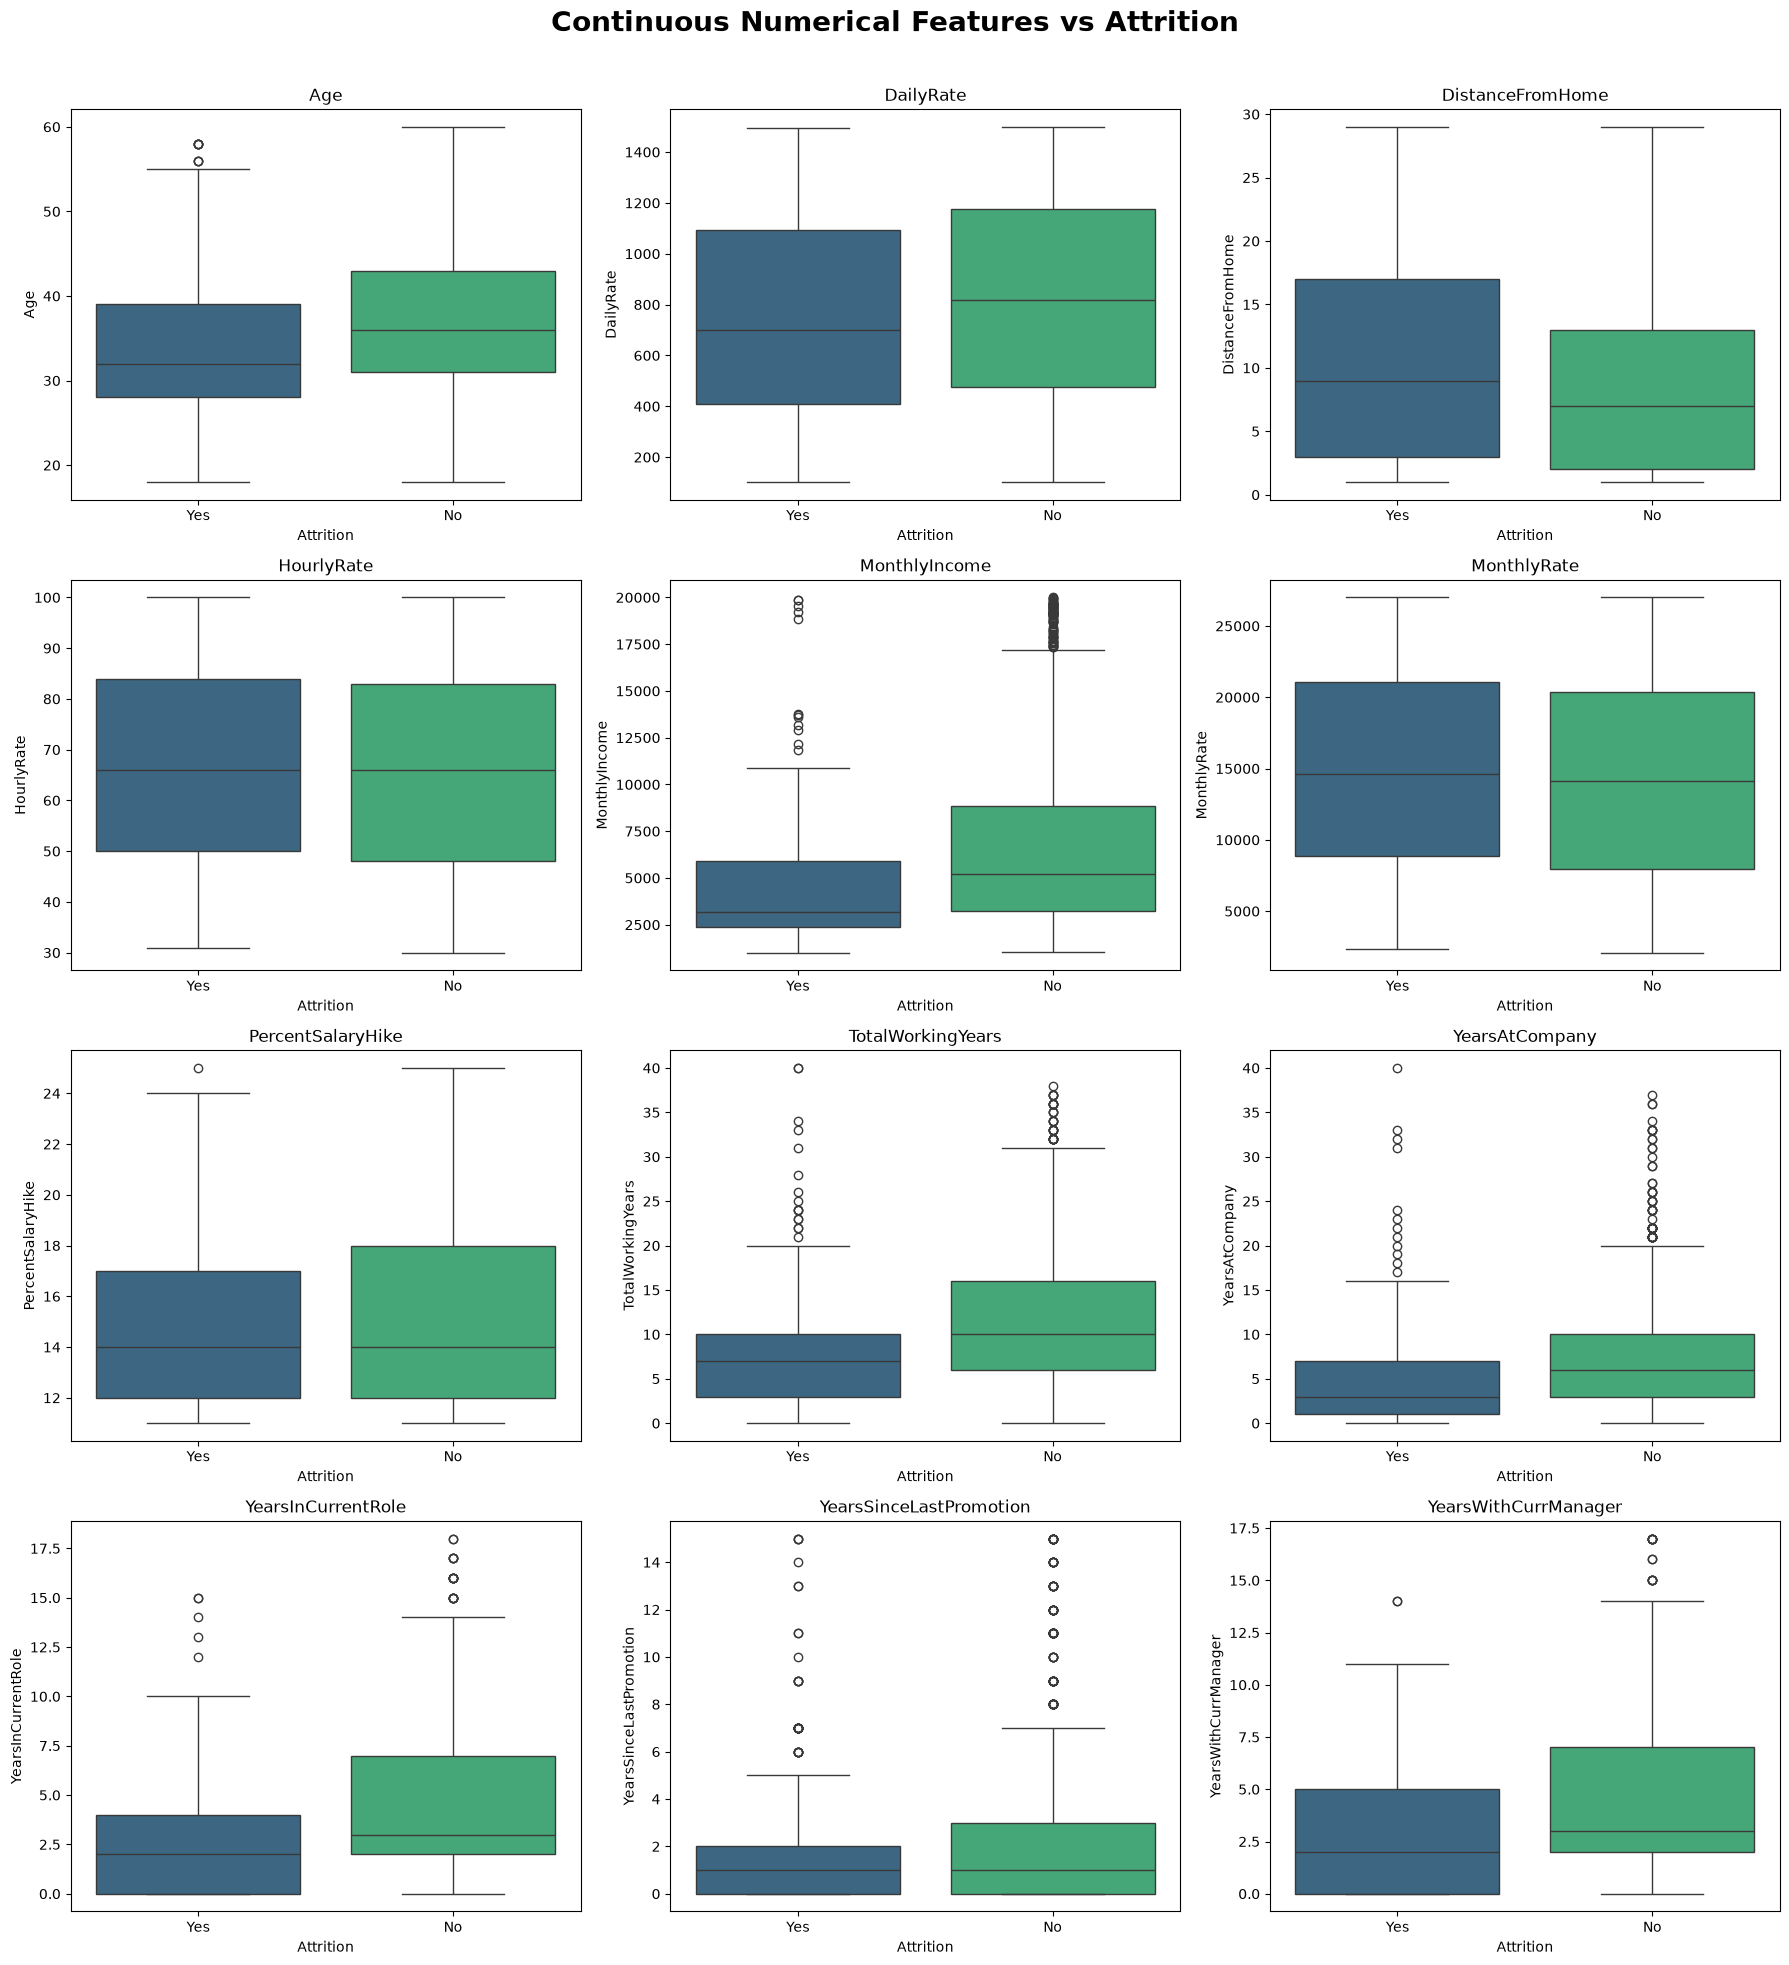

In [16]:
continuous_numerical_features = [
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "PercentSalaryHike",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

n_cols = 3
n_rows = math.ceil(len(continuous_numerical_features) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

# Overall title
fig.suptitle(
    'Continuous Numerical Features vs Attrition',
    fontsize=20,
    fontweight='bold'
)

axes = axes.flatten()

for i, col in enumerate(continuous_numerical_features):

    sns.boxplot(
        data=df,
        x='Attrition',
        y=col,
        hue='Attrition',
        palette='viridis',
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel('Attrition')

# Remove unused subplots
for j in range(len(continuous_numerical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

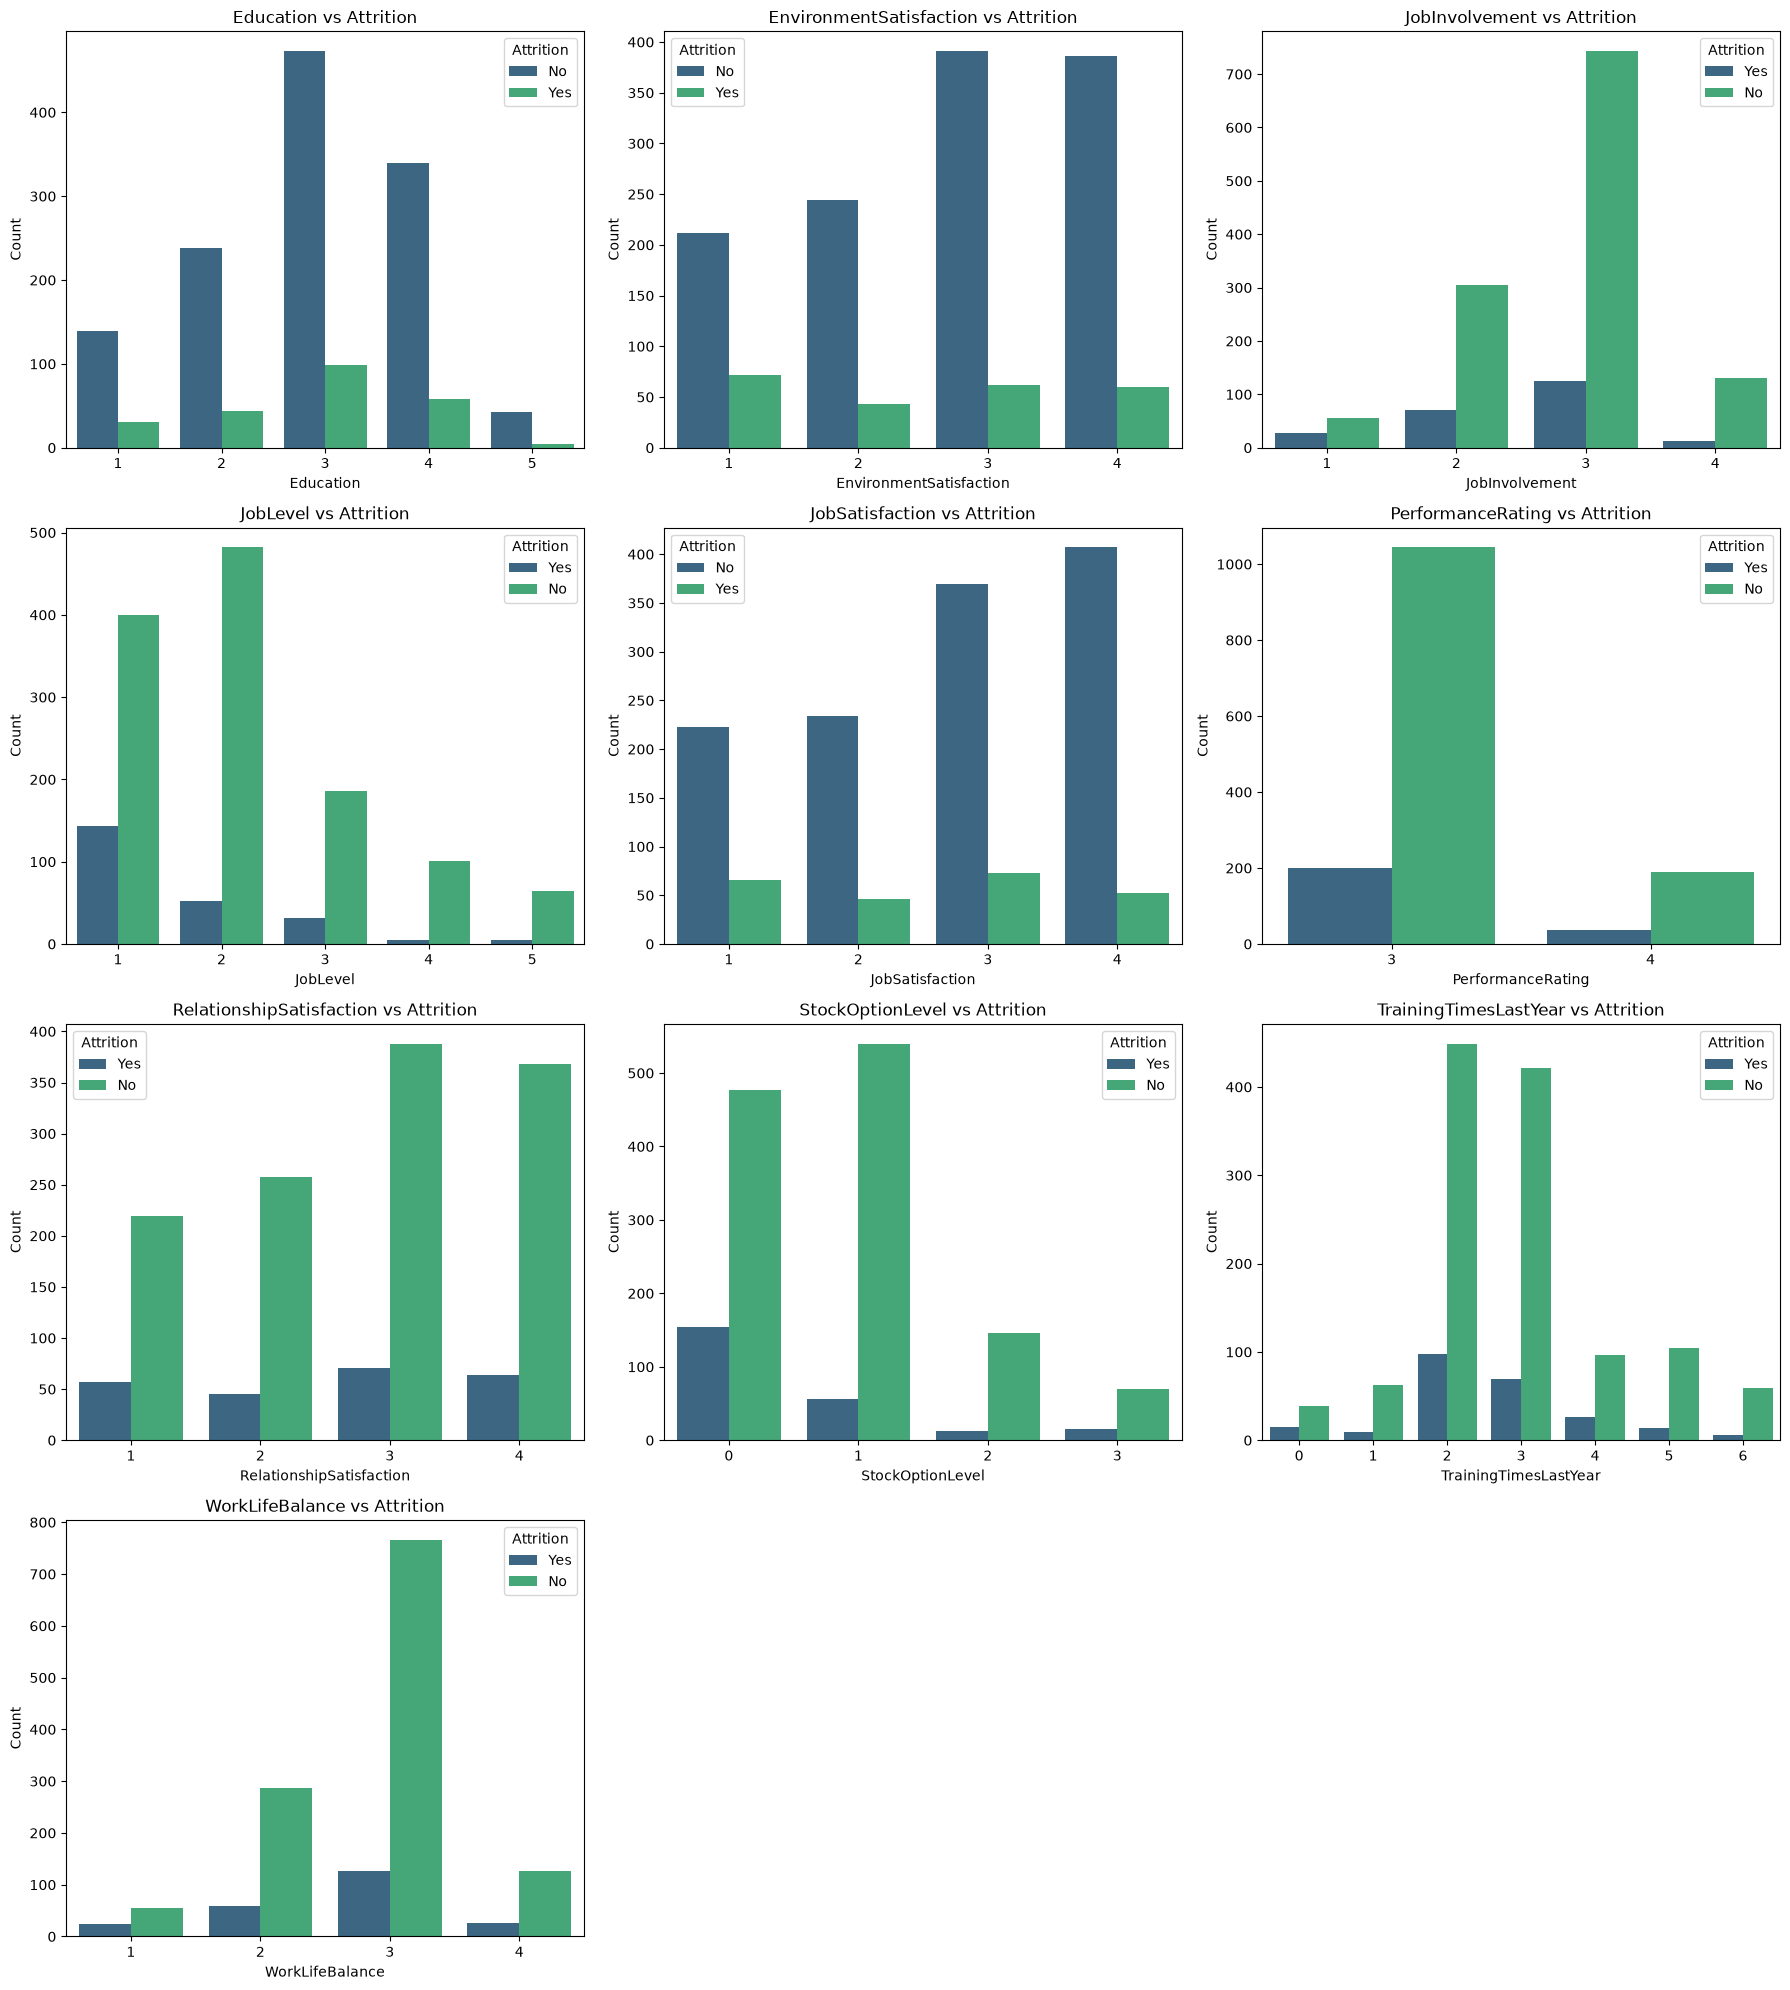

In [17]:
numerical_categorical_features = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "TrainingTimesLastYear",
    "WorkLifeBalance"
]

n_cols = 3
n_rows = math.ceil(len(numerical_categorical_features) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numerical_categorical_features):

    sns.countplot(
        data=df,
        x=col,
        hue='Attrition',
        palette='viridis',
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs Attrition')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove unused subplots
for j in range(len(numerical_categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Observation

The correlation analysis indicates a few moderately correlated feature groups, particularly among tenure-related variables (YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager) and compensation-related variables (JobLevel and MonthlyIncome).

No features were removed based solely on correlation, as the observed relationships are expected from a business perspective and the feature set remains manageable for model training.

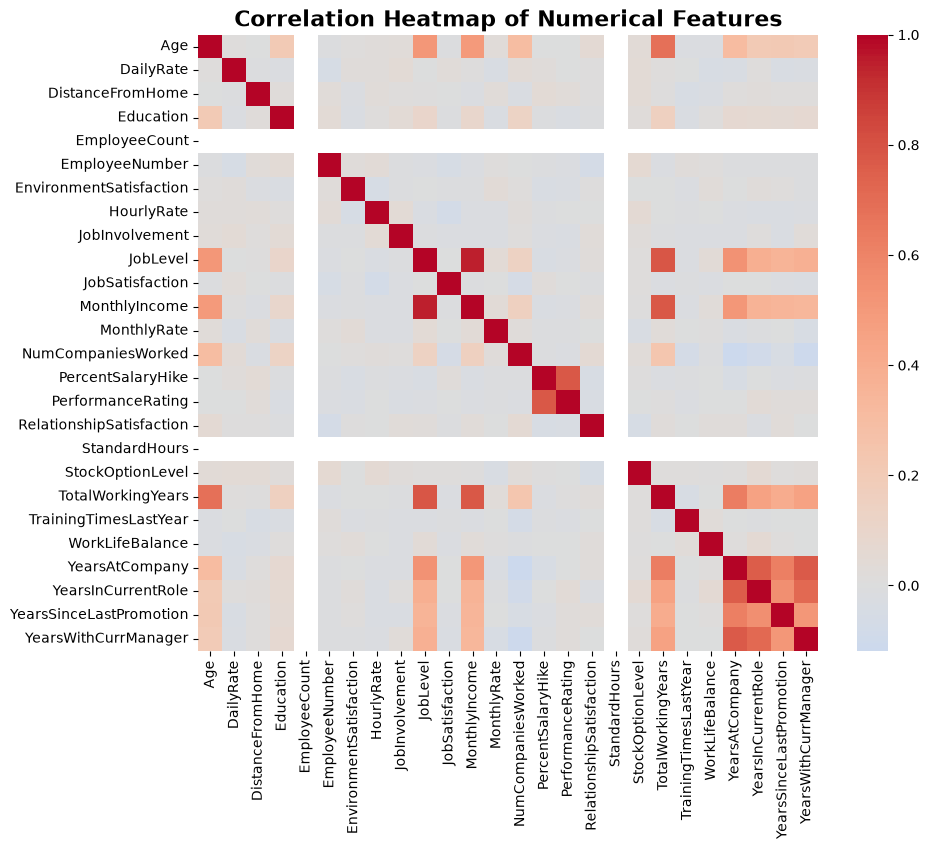

In [18]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    cmap='coolwarm',
    center=0
)

plt.title(
    'Correlation Heatmap of Numerical Features',
    fontsize=16,
    fontweight='bold'
)

plt.show()

## Step 2: Data Preprocessing

Prepare the dataset for machine learning by applying feature encoding and scaling techniques.

### Feature Encoding

Categorical features were encoded based on their characteristics:

- **Ordinal:** BusinessTravel
- **One-Hot:** Department, EducationField, JobRole, MaritalStatus
- **Binary:** Gender, OverTime
- **Target Encoding:** Attrition (No = 0, Yes = 1)

The selected encoding techniques preserve the semantic meaning of each feature while preparing the dataset for model training.

In [19]:
# remove not required columns - EmployeeCount, EmployeeNumber, over18, StandardHours
df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], inplace=True)

In [20]:
# train/test/split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['Attrition']),
    df['Attrition'],
    test_size=0.2,
    random_state=42)

In [21]:
# Encode Target Variable
y_train = y_train.map({
    'No': 0,
    'Yes': 1
})

y_test = y_test.map({
    'No': 0,
    'Yes': 1
})

In [22]:
# feature groups

# ordinal encoding for the following features

ordinal_features = [
    'BusinessTravel'
]


ordinal_encoder = OrdinalEncoder(
    categories=[
        [
            'Non-Travel',
            'Travel_Rarely',
            'Travel_Frequently'
        ]
    ]
)

# binary encoding for the following features

binary_features = [
    'Gender',
    'OverTime'
]
binary_encoder = OrdinalEncoder()

# one hot encoding for the following features
one_hot_features = [
    'Department',
    'EducationField',
    'JobRole',
    'MaritalStatus'
]

one_hot_encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'ordinal',
            ordinal_encoder,
            ordinal_features
        ),
        (
            'binary',
            binary_encoder,
            binary_features
        ),
        (
            'onehot',
            one_hot_encoder,
            one_hot_features
        )
    ],
    remainder='passthrough'
)

In [23]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [24]:
feature_names = preprocessor.get_feature_names_out()

In [25]:
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=feature_names,
    index=X_train.index
)


X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=feature_names,
    index=X_test.index
)

### Feature Scaling

The features were standardized using **StandardScaler**, transforming them to have a mean of 0 and a standard deviation of 1. This helps algorithms converge efficiently and prevents features with larger magnitudes from dominating the learning process.

In [26]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train_encoded)

# Transform test data
X_test_scaled = scaler.transform(X_test_encoded)

In [27]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_encoded.columns,
    index=X_train_encoded.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_encoded.columns,
    index=X_test_encoded.index
)

X_train_scaled.head()

,ordinal__BusinessTravel,binary__Gender,binary__OverTime,onehot__Department_Research & Development,onehot__Department_Sales,onehot__EducationField_Life Sciences,onehot__EducationField_Marketing,onehot__EducationField_Medical,onehot__EducationField_Other,onehot__EducationField_Technical Degree,onehot__JobRole_Human Resources,onehot__JobRole_Laboratory Technician,onehot__JobRole_Manager,onehot__JobRole_Manufacturing Director,onehot__JobRole_Research Director,onehot__JobRole_Research Scientist,onehot__JobRole_Sales Executive,onehot__JobRole_Sales Representative,onehot__MaritalStatus_Married,onehot__MaritalStatus_Single,remainder__Age,remainder__DailyRate,remainder__DistanceFromHome,remainder__Education,remainder__EnvironmentSatisfaction,remainder__HourlyRate,remainder__JobInvolvement,remainder__JobLevel,remainder__JobSatisfaction,remainder__MonthlyIncome,remainder__MonthlyRate,remainder__NumCompaniesWorked,remainder__PercentSalaryHike,remainder__PerformanceRating,remainder__RelationshipSatisfaction,remainder__StockOptionLevel,remainder__TotalWorkingYears,remainder__TrainingTimesLastYear,remainder__WorkLifeBalance,remainder__YearsAtCompany,remainder__YearsInCurrentRole,remainder__YearsSinceLastPromotion,remainder__YearsWithCurrManager
1097,-0.184671,0.814473,-0.63641,0.732977,-0.665541,-0.846634,-0.343323,-0.676202,-0.249661,3.262448,-0.19245,2.182821,-0.268355,-0.316376,-0.247733,-0.509019,-0.524870,-0.260998,-0.937334,-0.662882,-1.388559,-1.108139,1.440396,-0.863356,0.279706,-0.472832,-1.012340,-0.932274,-1.582336,-0.868277,-0.601895,-1.059168,-0.339249,-0.429290,-0.639822,2.547471,-1.167368,0.157319,0.357435,-0.974263,-0.888208,-0.676110,-1.142448
727,-2.073134,0.814473,-0.63641,0.732977,-0.665541,1.181149,-0.343323,-0.676202,-0.249661,-0.306518,-0.19245,-0.458123,-0.268355,-0.316376,-0.247733,1.964562,-0.524870,-0.260998,-0.937334,1.508564,-2.040738,-1.263481,-0.522699,-0.863356,-0.639104,0.309374,0.389912,-0.932274,1.152834,-1.132807,-0.115318,-0.659431,-0.066365,-0.429290,1.211176,-0.945525,-1.423397,-0.613546,0.357435,-1.138573,-1.165051,-0.676110,-1.142448
254,-0.184671,0.814473,-0.63641,-1.364300,1.502537,-0.846634,2.912709,-0.676202,-0.249661,-0.306518,-0.19245,-0.458123,-0.268355,-0.316376,-0.247733,-0.509019,1.905235,-0.260998,-0.937334,-0.662882,-0.845077,1.103647,1.317703,-0.863356,1.198515,-1.059487,0.389912,-0.025447,1.152834,0.116537,-0.503933,-0.259693,-0.339249,-0.429290,1.211176,0.218807,-0.143254,-0.613546,0.357435,-0.645643,-0.611364,-0.676110,-0.575084
1175,-0.184671,0.814473,-0.63641,0.732977,-0.665541,-0.846634,-0.343323,1.478848,-0.249661,-0.306518,-0.19245,-0.458123,-0.268355,3.160800,-0.247733,-0.509019,-0.524870,-0.260998,1.066856,-0.662882,0.241886,-0.758001,0.336155,0.099933,1.198515,-0.032841,0.389912,-0.025447,-0.670613,-0.231070,-0.931675,0.539781,1.570943,2.329427,0.285677,-0.945525,-0.527297,0.157319,0.357435,-0.317023,-0.057676,-0.355244,-1.142448
1341,-0.184671,0.814473,-0.63641,0.732977,-0.665541,1.181149,-0.343323,-0.676202,-0.249661,-0.306518,-0.19245,2.182821,-0.268355,-0.316376,-0.247733,-0.509019,-0.524870,-0.260998,-0.937334,-0.662882,-0.627685,-1.204303,1.317703,0.099933,-0.639104,1.091580,0.389912,-0.025447,0.241111,-0.464366,0.606876,-0.659431,-1.157903,-0.429290,-1.565321,0.218807,-0.143254,-0.613546,0.357435,0.504527,1.049700,-0.676110,-0.575084


### Handling Class Imbalance

The target variable is imbalanced (~84% No, ~16% Yes). **SMOTE** (Synthetic Minority Over-sampling Technique) is applied on the training set to generate synthetic minority class samples and balance the class distribution.

> **Note:** SMOTE is applied only on the training data to prevent data leakage.

In [28]:
from imblearn.over_sampling import SMOTE

print('Class distribution before SMOTE:')
print(y_train.value_counts())
print(f'Ratio: {y_train.value_counts()[1] / len(y_train):.2%} positive')

Class distribution before SMOTE:
Attrition
0    978
1    198
Name: count, dtype: int64
Ratio: 16.84% positive


In [29]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

print('Class distribution after SMOTE:')
print(y_train_resampled.value_counts())
print(f'Ratio: {y_train_resampled.value_counts()[1] / len(y_train_resampled):.2%} positive')

Class distribution after SMOTE:
Attrition
0    978
1    978
Name: count, dtype: int64
Ratio: 50.00% positive


## Step 3: Model Building

The preprocessed dataset is now ready for training and evaluating classification models. Multiple algorithms will be compared using appropriate performance metrics to identify the best model for predicting employee attrition.

### Models

Five classifiers are trained on the SMOTE-resampled training data:

1. **Logistic Regression** — linear baseline
2. **Decision Tree** — interpretable, non-linear
3. **Random Forest** — ensemble of trees, reduces overfitting
4. **Gradient Boosting** — sequential boosting, high accuracy
5. **K-Nearest Neighbors** — distance-based, no assumptions on distribution

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
}

In [31]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model
    print(f'{name}: trained')

Logistic Regression: trained
Decision Tree: trained
Random Forest: trained
Gradient Boosting: trained
KNN: trained


## Step 4: Model Evaluation

Each model is evaluated on the **original (imbalanced) test set** using:

- **Accuracy** — overall correctness
- **Precision** — of predicted positives, how many are truly positive
- **Recall** — of actual positives, how many were caught (critical for attrition)
- **F1 Score** — harmonic mean of precision and recall
- **ROC-AUC** — discrimination ability across all thresholds
- **Confusion Matrix** — breakdown of TP, FP, TN, FN

In [32]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1 Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df.sort_values('F1 Score', ascending=False)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Gradient Boosting,0.8810,0.5833,0.3590,0.4444,0.7815
Logistic Regression,0.7653,0.3026,0.5897,0.4000,0.7654
KNN,0.6735,0.2336,0.6410,0.3425,0.6828
Random Forest,0.8878,0.8000,0.2051,0.3265,0.7407
Decision Tree,0.7959,0.2162,0.2051,0.2105,0.5457


### Confusion Matrices

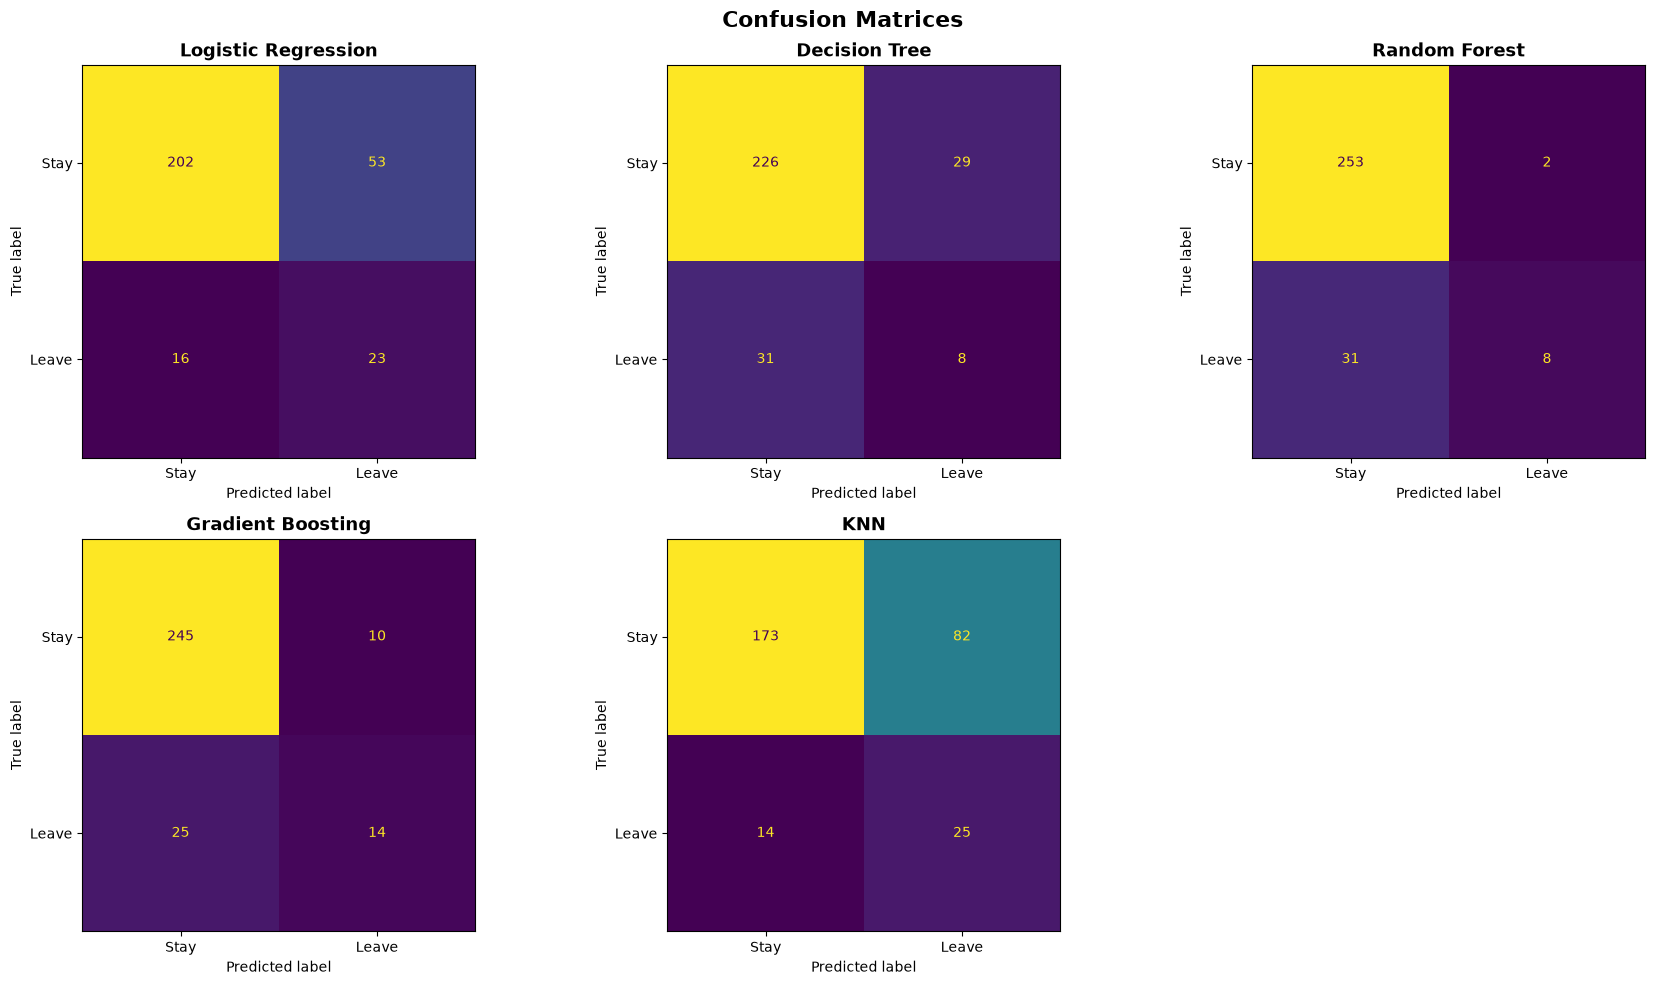

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Leave'])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(name, fontsize=13, fontweight='bold')

fig.delaxes(axes[-1])
plt.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### ROC Curves

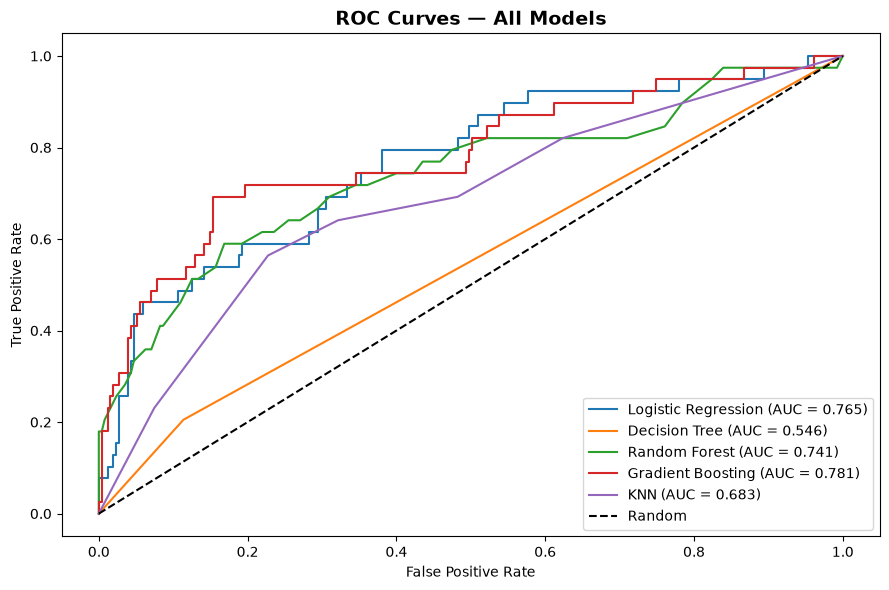

In [34]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 6))

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 5: Feature Importance

Feature importance reveals which attributes most influence attrition predictions. Tree-based models (Decision Tree, Random Forest, Gradient Boosting) expose built-in importances. Logistic Regression uses absolute coefficients as a proxy.

> **Best model** is selected based on highest F1 Score from the evaluation above.

In [35]:
# Select best model by F1 Score
best_model_name = results_df['F1 Score'].idxmax()
best_model = trained_models[best_model_name]
print(f'Best model: {best_model_name}')
print(results_df.loc[best_model_name])

Best model: Gradient Boosting
Accuracy     0.8810
Precision    0.5833
Recall       0.3590
F1 Score     0.4444
ROC-AUC      0.7815
Name: Gradient Boosting, dtype: float64


In [36]:
feature_cols = X_train_resampled.columns.tolist()

# Clean up column names for readability
clean_names = [
    col.replace('ordinal__', '').replace('binary__', '')
       .replace('onehot__', '').replace('remainder__', '')
    for col in feature_cols
]

# Extract importances based on model type
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = abs(best_model.coef_[0])
else:
    raise ValueError(f'{best_model_name} does not support feature importances')

importance_df = pd.DataFrame({
    'Feature':    clean_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

importance_df.head(15)

,Feature,Importance
0,OverTime,0.330286
1,StockOptionLevel,0.108424
2,JobLevel,0.059870
3,BusinessTravel,0.057177
4,JobSatisfaction,0.051108
5,YearsWithCurrManager,0.045719
6,WorkLifeBalance,0.043052
7,JobInvolvement,0.027129
8,MonthlyIncome,0.026850
9,EnvironmentSatisfaction,0.026394


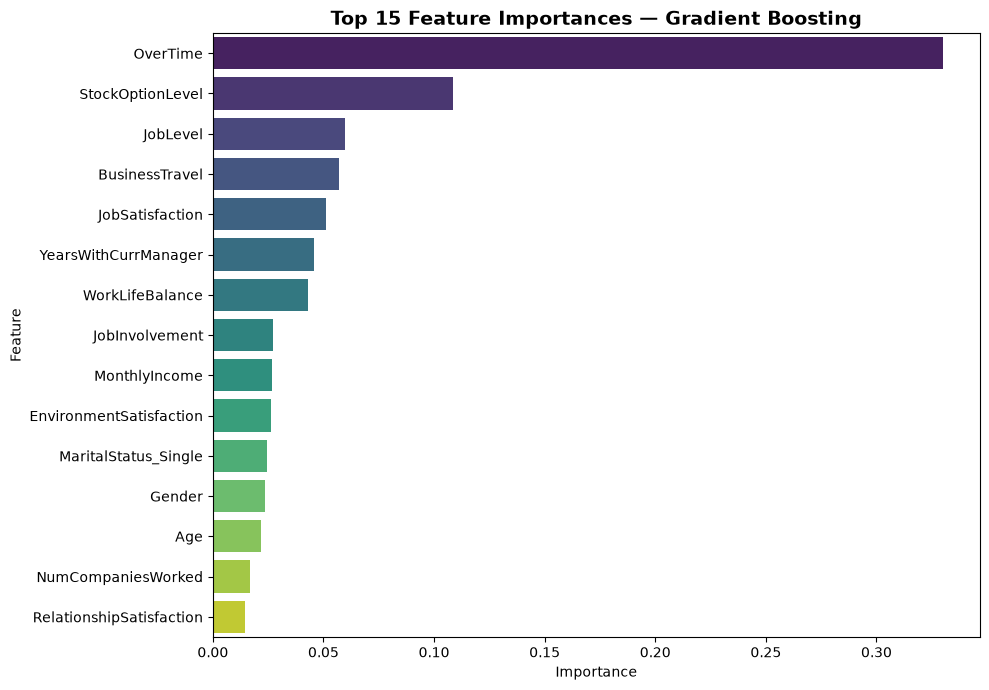

In [37]:
top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title(
    f'Top {top_n} Feature Importances — {best_model_name}',
    fontsize=14, fontweight='bold'
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Feature Importance — All Tree-Based Models

Compare how each tree-based model ranks the top features.

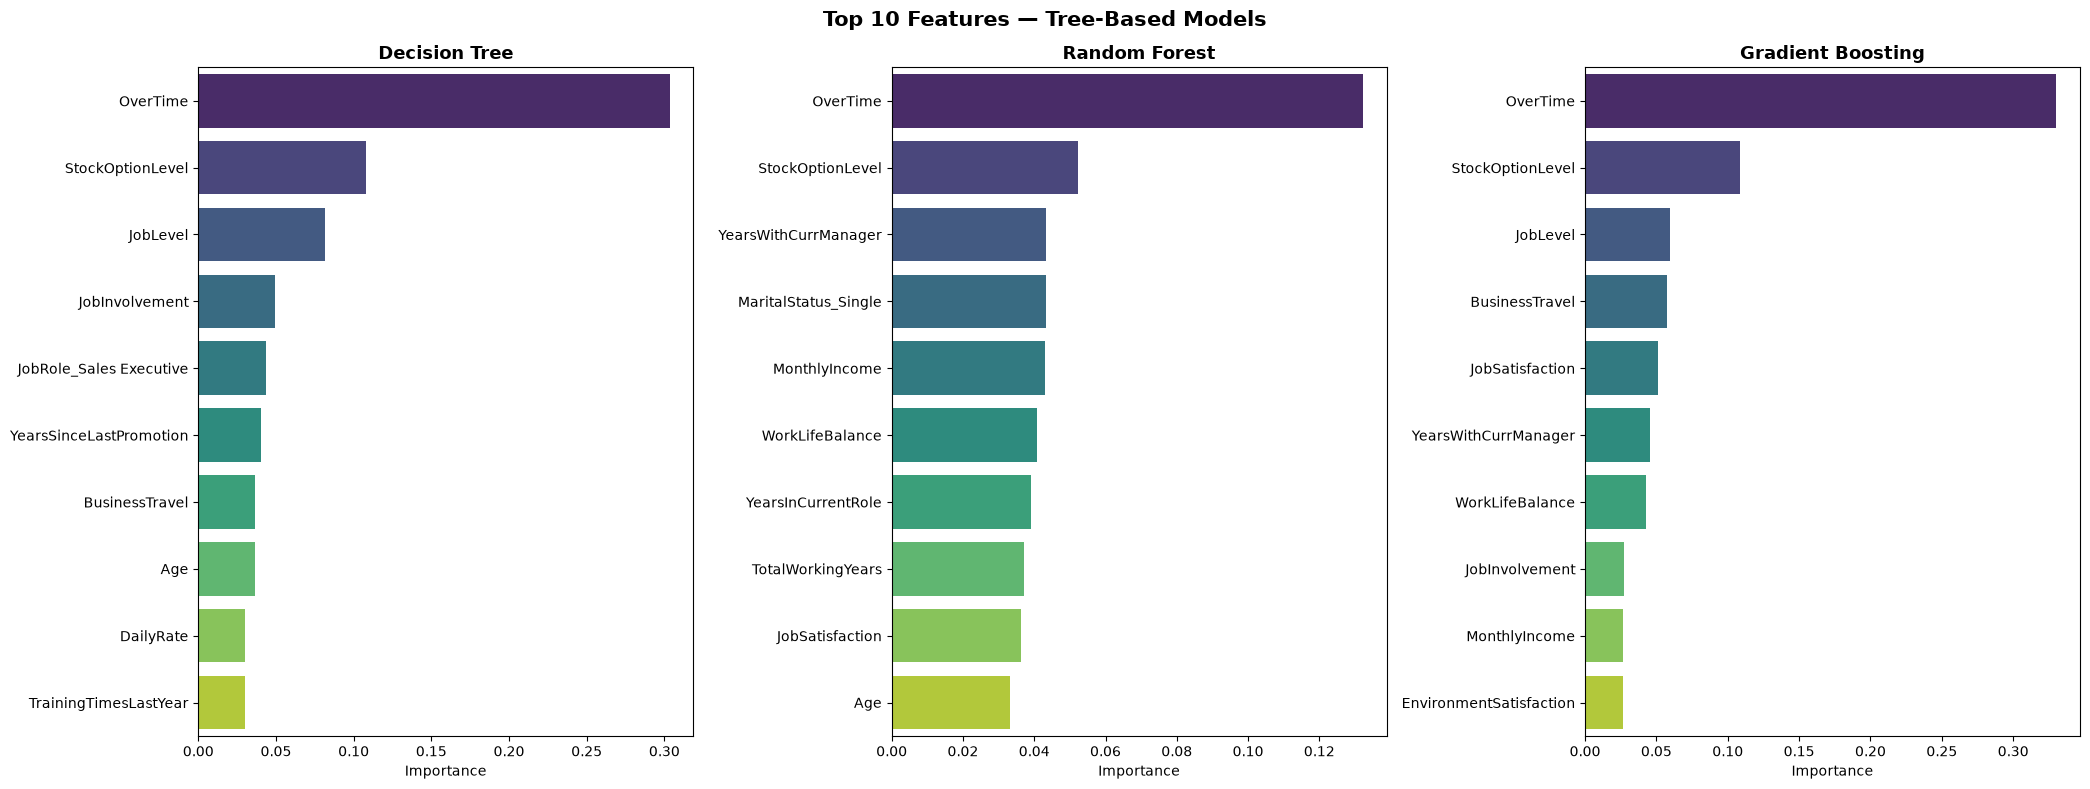

In [38]:
tree_models = {
    name: model for name, model in trained_models.items()
    if hasattr(model, 'feature_importances_')
}

fig, axes = plt.subplots(1, len(tree_models), figsize=(7 * len(tree_models), 8))

if len(tree_models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, tree_models.items()):
    df_imp = pd.DataFrame({
        'Feature':    clean_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)

    sns.barplot(
        data=df_imp, x='Importance', y='Feature',
        hue='Feature', palette='viridis', legend=False, ax=ax
    )
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.set_ylabel('')

plt.suptitle('Top 10 Features — Tree-Based Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Save Best Model

The best performing model (by F1 Score) is saved to `model.pkl` using `joblib`. The preprocessor and scaler are saved alongside so the full pipeline can be reconstructed for inference without retraining.

In [39]:
import joblib

# Save best model
joblib.dump(best_model, 'model.pkl')

# Save preprocessor and scaler for inference
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f'Saved model   : model.pkl  ({best_model_name})')
print(f'Saved preprocessor : preprocessor.pkl')
print(f'Saved scaler       : scaler.pkl')

Saved model   : model.pkl  (Gradient Boosting)
Saved preprocessor : preprocessor.pkl
Saved scaler       : scaler.pkl


In [40]:
# Verify: reload and confirm predictions match
loaded_model = joblib.load('model.pkl')
y_pred_loaded = loaded_model.predict(X_test_scaled)
y_pred_original = best_model.predict(X_test_scaled)

match = (y_pred_loaded == y_pred_original).all()
print(f'Predictions match after reload: {match}')

Predictions match after reload: True
